# Instructor Effectiveness Analysis

This project analyzes instructor effectiveness using course engagement and performance metrics.

The objective is to identify factors that influence course completion rate and build a machine learning model that predicts student completion.

Steps performed in this project:

1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Building
6. Model Evaluation
7. Business Insights

In [26]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [28]:
df = pd.read_excel("instructor_effectiveness_dataset_2000_rows.xlsx")
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [30]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


## Data Cleaning

In [31]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


In [32]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_799/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [33]:
df_model = df.drop(['batch_id','instructor_id','course_id'], axis=1)
df_model.head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


## Exploratory Data Analysis

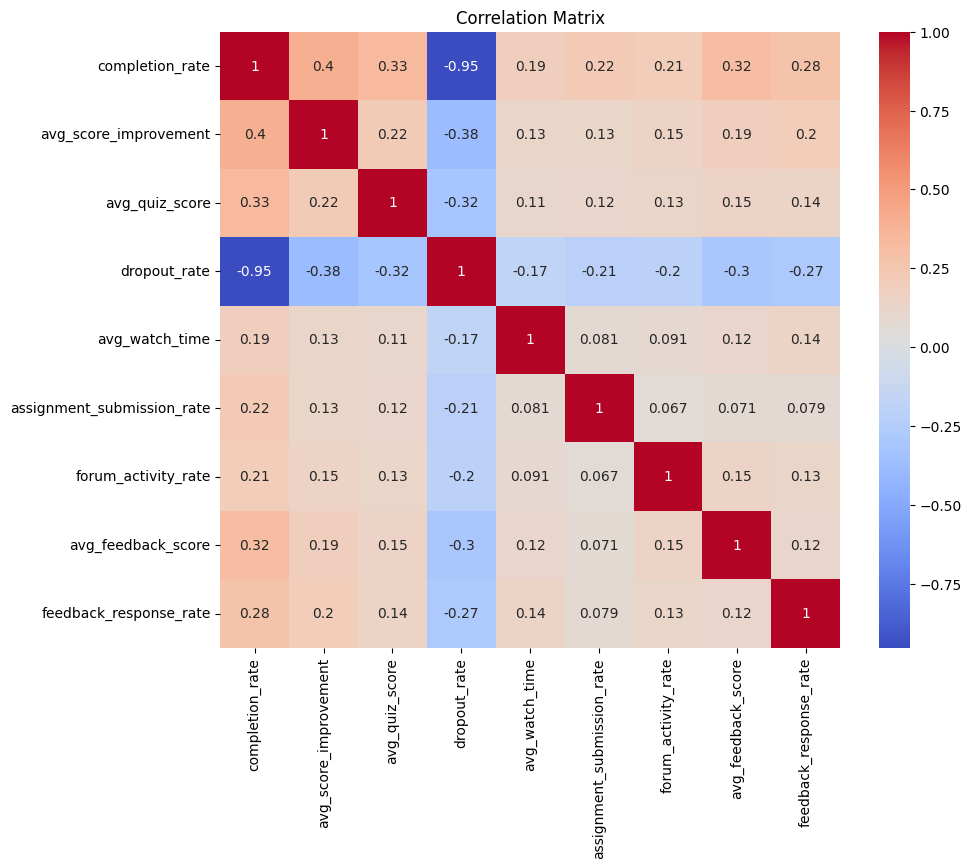

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(df_model.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

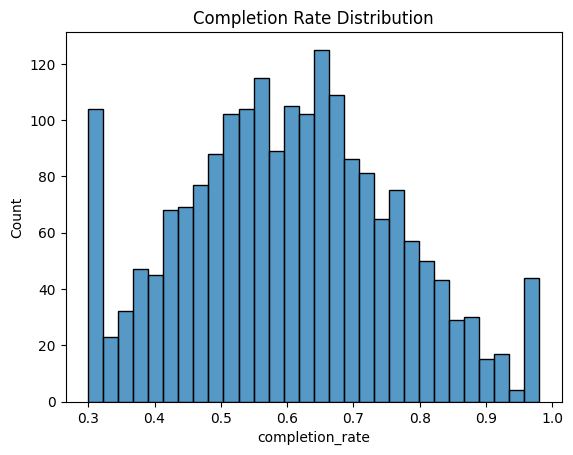

In [35]:
sns.histplot(df_model['completion_rate'], bins=30)
plt.title("Completion Rate Distribution")
plt.show()

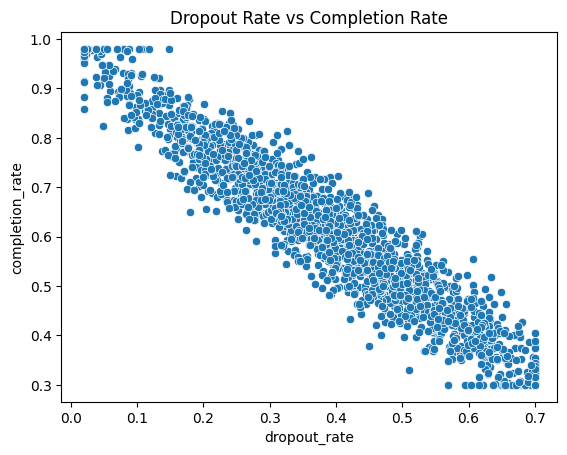

In [36]:
sns.scatterplot(x='dropout_rate', y='completion_rate', data=df_model)
plt.title("Dropout Rate vs Completion Rate")
plt.show()

In [37]:
X = df_model.drop('completion_rate', axis=1)
y = df_model['completion_rate']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Building

In [39]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [40]:
y_pred = model.predict(X_test)

## Model Evaluation

In [41]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.002319697212486956
R2 Score: 0.9158199565124171


## Feature Importance

In [42]:
importance = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)
importance_df

,Feature,Importance
2,dropout_rate,0.920394
0,avg_score_improvement,0.014070
7,feedback_response_rate,0.012206
5,forum_activity_rate,0.010802
1,avg_quiz_score,0.010769
3,avg_watch_time,0.010755
6,avg_feedback_score,0.010669
4,assignment_submission_rate,0.010335


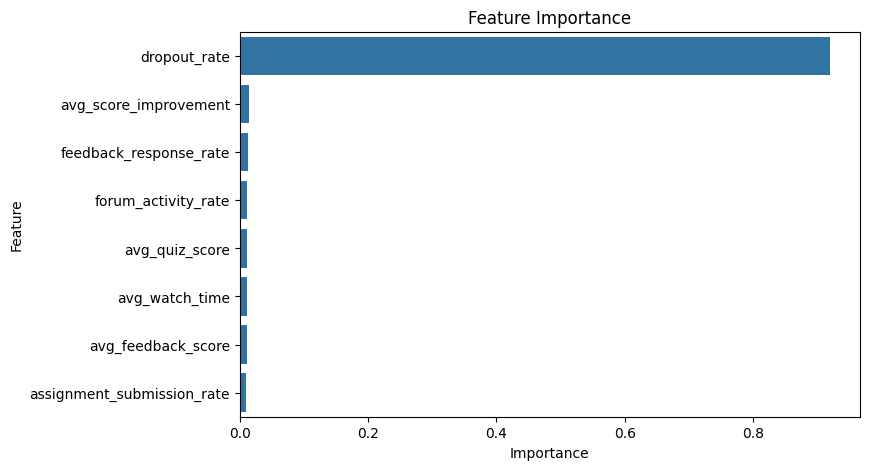

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

Key factors influencing course completion rate include:

• Assignment submission rate
• Average quiz score
• Forum activity rate
• Average watch time

Higher student engagement significantly improves completion rates.

To improve instructor effectiveness and course completion:

1. Encourage higher assignment submission rates.
2. Improve student engagement in discussion forums.
3. Provide interactive learning materials to increase watch time.
4. Monitor dropout patterns and intervene early.

This analysis identified key engagement metrics that influence course completion.
The machine learning model successfully predicts completion rates using student engagement and performance features.
Educational platforms can use these insights to improve course quality and increase student success.